In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

from PIL import Image
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

from datasets import load_dataset, Dataset

from src.kitti_tracking import KittiDataset
from src.kitti_tracking_hf import KittiHFIterableDataset

from src.agents.tools.inpainting import InpaintingTool

from matplotlib import pyplot as plt

/home/leonard/anaconda3/envs/agentic/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/leonard/anaconda3/envs/agentic/lib/python3.10/site-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


In [3]:
root_dir = "/mnt/ssd/kitti_tracking"
n_steps, n_pred_steps = 16, 0

clip_segm_name = "CIDAS/clipseg-rd64-refined"
clip_segm_processor = CLIPSegProcessor.from_pretrained(clip_segm_name, use_fast=True)
clip_segm_model = CLIPSegForImageSegmentation.from_pretrained(clip_segm_name)#.to(device)

dataset_builder = KittiHFIterableDataset(
	root_dir=root_dir,
	split="training",
	n_steps=n_steps,
	n_pred_steps=n_pred_steps,
	transform=T.Compose([
		T.Resize((120, 320)),
	])
)
dataset = dataset_builder.to_hf_dataset()

In [9]:
prompts = ['people', 'vehicles']
patch_size, threshold, drop_p = 16, 0.3, 0.0
size = (176, 176)

with torch.no_grad():
    for i, sample in enumerate(dataset):
        images = sample['rgb']
        masks = []
        for img in images:

            inputs = clip_segm_processor(
                text=prompts, images=[img]*len(prompts),
                return_tensors="pt"
            )
            outputs = clip_segm_model(**inputs)  # (C, H, W)
            # combined_mask from all classes
            _m = (np.random.random(outputs.logits.shape[0]) >= drop_p).astype(int)
            mask = outputs.logits.sigmoid().float().cpu().numpy() * _m[:, None, None]
            mask = mask.max(0)
            sem_mask = Image.fromarray(255 * (mask > 0.5).astype(np.uint8)).resize(size)
            # plt.imshow(sem_mask)
            # plt.axis('off')
            # plt.show()

            h, w = sem_mask.size
            grid = (np.random.random((w // patch_size, h // patch_size)) < threshold).astype(np.uint8)
            rand_mask = Image.fromarray(grid.repeat(patch_size, axis=0).repeat(patch_size, axis=1)*255, mode="L")

            # plt.imshow(rand_mask)
            # plt.axis('off')
            # plt.show()

            mask = Image.composite(sem_mask.resize(rand_mask.size), rand_mask, sem_mask.resize(rand_mask.size))
            masks.append(mask)

            # break
            
        break

# mask

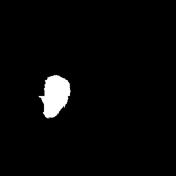

In [10]:
sem_mask

In [ ]:
inpainting_tool = InpaintingTool(
    ckpt="./checkpoints/dstt.pth",
)
inpainting_tool.reset()
for img, mask in zip(images, masks):
    masked_img = Image.composite(img, Image.new("RGB", img.size, 0), mask.resize(img.size))

    recon_img = inpainting_tool(masked_img, mask)

    # break

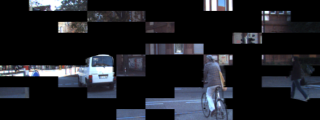

In [22]:
masked_img

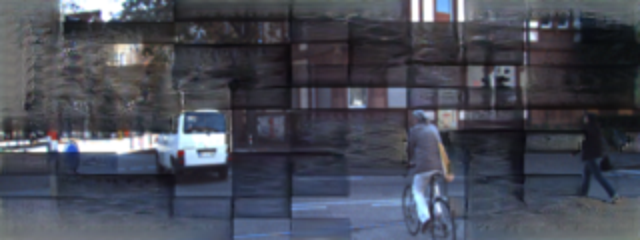

In [23]:
recon_img.resize((640, 240))